In [43]:
import os
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
import plotly.express as px

In [44]:
study_group = "multi"
res_range = range(101)

In [45]:
layout_path = f"results/layouts/experiment_{id_exp}.pkl"
with open(layout_path, "rb") as f:
    truc = pkl.load(f)
truc

[[[[1, 2], [18, 4]], [[0, 1], [16, 2]]],
 ['Heloise', 'Gertrude', 'Didier', 'Bernard'],
 [('halfling_rogue.yml', 'Bernard'), ('high_elf_fighter.yml', 'Gertrude')],
 [('halfling_rogue.yml', 'Heloise'), ('halfling_rogue.yml', 'Didier')]]

In [46]:
def read_results(exp_id, exp_type):
    result_path = f"results/{exp_type}/experiment_{exp_id}.pkl"
    with open(result_path, "rb") as g:
        res = pkl.load(g)
    return res
read_results(96, "solo").keys(), read_results(93, "solo")["metrics"]

(dict_keys(['a', 'b', 'conversations', 'metrics', 'score', 'backlog']),
 {'win': True,
  'turns_taken': 60,
  'survivors': {'Francois': (16, 16), 'Alysha': (13, 24)}})

In [55]:
res_mul = []
res_solo = []
c= 0
for exp_id in res_range:
    m_score = read_results(exp_id=exp_id, exp_type="multi")["score"]
    s_score = read_results(exp_id=exp_id, exp_type="solo")["score"]
    res_mul.append(m_score)
    res_solo.append(s_score)
    c += m_score>s_score

print(f"Average score for the communicating experiment : {sum(res_mul)/len(res_mul)}")
print(f"Average score for the solo experiment : {sum(res_solo)/len(res_solo)}")
res_mul = np.array(res_mul)
res_solo = np.array(res_solo)
res = [[r_mul, "Communicating agents"] for r_mul in res_mul] + [[r_solo, "Solo agent"] for r_solo in res_solo]
df = pd.DataFrame(res, columns=["Score", "Agent type"])
fig = px.box(df, x="Score", color="Agent type", points="all", width=1100, height=450, labels="Agent type")
fig.show()

Average score for the communicating experiment : -32.05775577557756
Average score for the solo experiment : -20.959570957095707


In [50]:
res_mul = []
res_solo = []
c= 0
for exp_id in res_range:
    m_score = len(read_results(exp_id=exp_id, exp_type="multi")["metrics"]["survivors"])
    s_score = len(read_results(exp_id=exp_id, exp_type="solo")["metrics"]["survivors"])
    res_mul.append(m_score)
    res_solo.append(s_score)
    c += m_score>s_score

print(f"Average score for the communicating experiment : {sum(res_mul)/len(res_mul)}")
print(f"Average score for the solo experiment : {sum(res_solo)/len(res_solo)}")
res_mul = np.array(res_mul)
res_solo = np.array(res_solo)
res = [[r_mul, "Communicating agents"] for r_mul in res_mul] + [[r_solo, "Solo agent"] for r_solo in res_solo]
df = pd.DataFrame(res, columns=["Score", "Agent type"])
fig = px.box(df, x="Score", color="Agent type", points="all", width=1100, height=450, labels="Agent type")
fig.show()

Average score for the communicating experiment : 0.8712871287128713
Average score for the solo experiment : 1.00990099009901


In [59]:
res_mul = []
res_solo = []
c= 0
for exp_id in res_range:
    m_score = read_results(exp_id=exp_id, exp_type="multi")["metrics"]["turns_taken"] - len(read_results(exp_id=exp_id, exp_type="multi")["conversations"])
    s_score = read_results(exp_id=exp_id, exp_type="solo")["metrics"]["turns_taken"]
    res_mul.append(m_score)
    res_solo.append(s_score)
    c += m_score>s_score

print(f"Average experiment length for the communicating experiment : {sum(res_mul)/len(res_mul)}")
print(f"Average experiment length for the solo experiment : {sum(res_solo)/len(res_solo)}")
res_mul = np.array(res_mul)
res_solo = np.array(res_solo)
res = [[r_mul, "Communicating agents"] for r_mul in res_mul] + [[r_solo, "Solo agent"] for r_solo in res_solo]
df = pd.DataFrame(res, columns=["Time step", "Agent type"])
fig = px.box(df, x="Time step", color="Agent type", points="all", width=1100, height=450, labels="Agent type")
fig.show()

Average experiment length for the communicating experiment : 78.35643564356435
Average experiment length for the solo experiment : 79.34653465346534


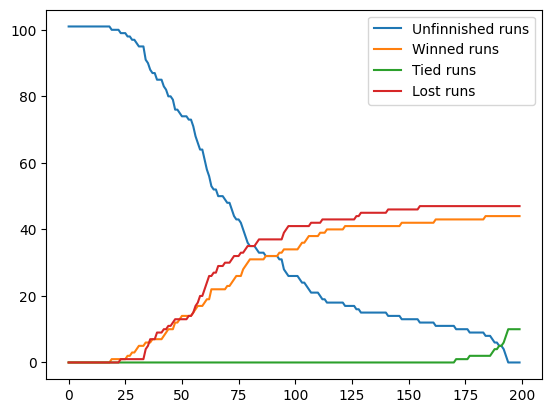

In [60]:
time = range(200)
not_done = np.array([len(res_range) for i in time])
won = np.array([0 for i in time])
tie = np.array([0 for i in time])
lost = np.array([0 for i in time])
exp_type = "multi"
for exp_id in res_range:
    exp_res = read_results(exp_id=exp_id, exp_type=exp_type)["metrics"]
    turn = exp_res["turns_taken"]
    not_done[turn:] -= 1
    if exp_res["win"]:
        won[turn:] += 1
    elif len([1 for name, (life, _) in exp_res["survivors"].items() if life > 0]):
        tie[turn:] += 1
    else:
        lost[turn:] += 1
plt.plot(not_done, label="Unfinnished runs")
plt.plot(won, label="Winned runs")
plt.plot(tie, label="Tied runs")
plt.plot(lost, label="Lost runs")
plt.legend()

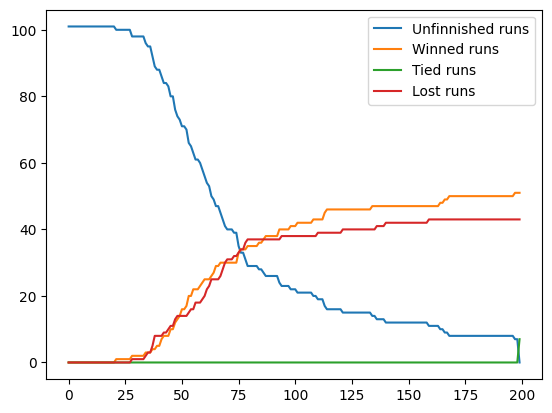

In [61]:
time = range(200)
not_done = np.array([len(res_range) for i in time])
won = np.array([0 for i in time])
tie = np.array([0 for i in time])
lost = np.array([0 for i in time])
exp_type = "solo"
for exp_id in res_range:
    exp_res = read_results(exp_id=exp_id, exp_type=exp_type)["metrics"]
    turn = exp_res["turns_taken"]
    not_done[turn:] -= 1
    if exp_res["win"]:
        won[turn:] += 1
    elif len([1 for name, (life, _) in exp_res["survivors"].items() if life > 0]):
        tie[turn:] += 1
    else:
        lost[turn:] += 1
plt.plot(not_done, label="Unfinnished runs")
plt.plot(won, label="Winned runs")
plt.plot(tie, label="Tied runs")
plt.plot(lost, label="Lost runs")
plt.legend()

In [66]:
res = read_results(92, "multi") 
res["backlog"]

[('Eric',
  (0, (0, 0), (0, 1), 2, 0),
  'attack Gertrude with melee weapon: dagger'),
 ('Eric', (9, (0, 0), (0, 1), 2, 0), 'two weapon attack bonus action'),
 ('Eric', (-1, (0, 0), (0, 0), 0, 0), 'end my turn'),
 ('Gertrude',
  (0, (0, 0), (0, -1), 15, 0),
  'attack Eric with melee weapon: rapier'),
 ('Gertrude',
  (8, (-1, -1), (0, 0), 0, 0),
  'Use Second Wind as a bonus action to recover some hit points.'),
 ('Gertrude', -1, 'communicate with Didier to coordinate strategy.'),
 ('Gertrude', -1, 0),
 ('Gertrude', (-1, (0, 0), (0, 0), 0, 0), 'end my turn'),
 ('Francois',
  (0, (0, 0), (-10, 1), 13, 1),
  'attack Didier with ranged weapon: longbow'),
 ('Francois',
  (-1, (0, 0), (0, 0), 0, 0),
  'End my turn as I have no available actions left this turn, only a bonus action and a reaction.'),
 ('Didier',
  (0, (0, 0), (0, 2), 13, 1),
  'attack Eric with ranged weapon: longbow'),
 ('Didier', (8, (-1, -1), (0, 0), 0, 0), 'second wind action'),
 ('Didier', (-1, (0, 0), (0, 0), 0, 0), 'end

In [67]:
res["conversations"]

[[('Gertrude',
   "Didier, Eric is already wounded and right in front of us. If we focus him down quickly, we can take him out before Francois gets involved. Let's both hit Eric—I'll try to block his escape!"),
  ('Didier',
   "Agreed, Gertrude. I'll attack Eric with everything I've got. Try to keep Francois away from us so we don't get surrounded. Once Eric is down, we'll focus on Francois together. Ready?"),
  (None, 'Conversation closed')],
 [('Gertrude',
   "Didier, Eric is down! Focus everything on Francois—let's keep him under pressure and don't give him room to maneuver. Move to get a clear line of sight if you need to, I'll follow your lead if you spot him first."),
  ('Didier',
   "Agreed, Gertrude. Let's sweep the area together. I'll stay in front and draw Francois out if he's nearby. Stay close so we can double up on him if he appears. Ready when you are!"),
  (None, 'Conversation closed')]]

In [69]:
res["metrics"]

{'win': False, 'turns_taken': 69, 'survivors': {}}